In [ ]:
#################################################################################################
# Import necessary libraries
#################################################################################################
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.inspection import PartialDependenceDisplay
from time import time
from pprint import pprint
%matplotlib inline
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style('darkgrid')
from scipy import stats
from scipy.stats import norm, skew

In [ ]:
#################################################################################################
# Import data
#################################################################################################
#Data_DF = pd.read_excel("MKGPC_dummy.xlsx")
from google.colab import files

### Upload the file manually
uploaded = files.upload() ###FILE TO UPLOAD IS IN 2024.06.11>Codes>DATASETS FOLDER>AfzaliDataset.xlsx

### Load the uploaded file into a DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(df.head())

Data_DF = df

Saving GPCACID_DATASET_toy.csv to GPCACID_DATASET_toy.csv
   Spodumene Flotation Tailings (wt.%)  SILICA FUME (wt. %)  Red Mud (wt.%)  \
0                                    0                  0.0               0   
1                                    0                  0.0               0   
2                                    0                  0.0               0   
3                                    0                  0.0               0   
4                                    0                  0.0               0   

   Metakaolin (wt.%)  Low-reactive Copper Mine Tailings (MT), g  Fly Ash (g)  \
0                0.0                                          0         2620   
1                0.0                                          0         2620   
2                0.0                                          0         2620   
3                0.0                                          0         2620   
4                0.0                                          0    

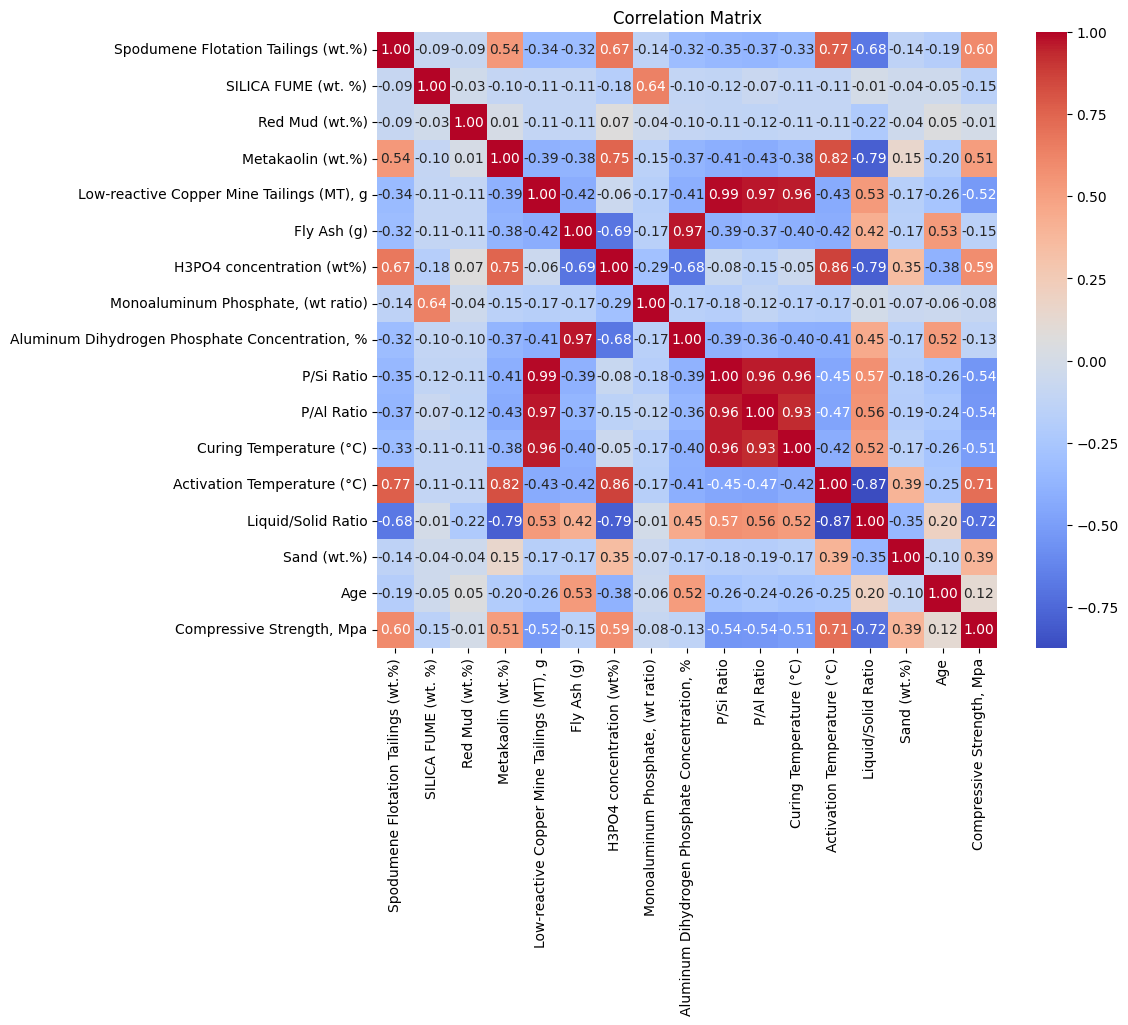

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#################################################################################################
# Create an array of features for model development
#################################################################################################
target_variable = 'Compressive Strength, Mpa'

# Extract feature names by excluding the target variable
Feature_Names = [col for col in Data_DF.columns if col != target_variable]

X = Data_DF[Feature_Names].to_numpy()
y = Data_DF[target_variable].to_numpy()

In [ ]:
#################################################################################################
# Split data for training and testing
#################################################################################################
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1)

In [ ]:
#################################################################################################
# Scale the data
#################################################################################################
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#################################################################################################
# Model training
#################################################################################################
model = XGBRegressor(objective ='reg:squarederror', n_estimators=5745, max_depth=5, learning_rate=0.00875)
model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.00875, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5745, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
#################################################################################################
# Make predictions on testing data
#################################################################################################
Y_Test_Pred = model.predict(X_test_scaled)

############ Model Accuracy ############
RMSE: 5.593
R-squared: 0.876
MAPE: 34.728
MAE: 3.242
########################################
 


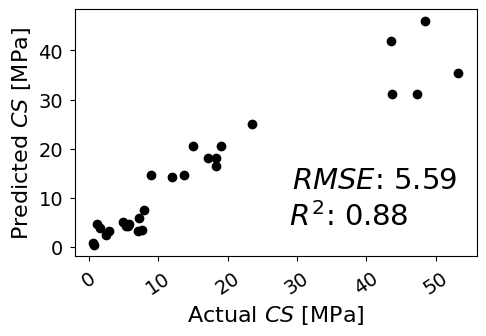

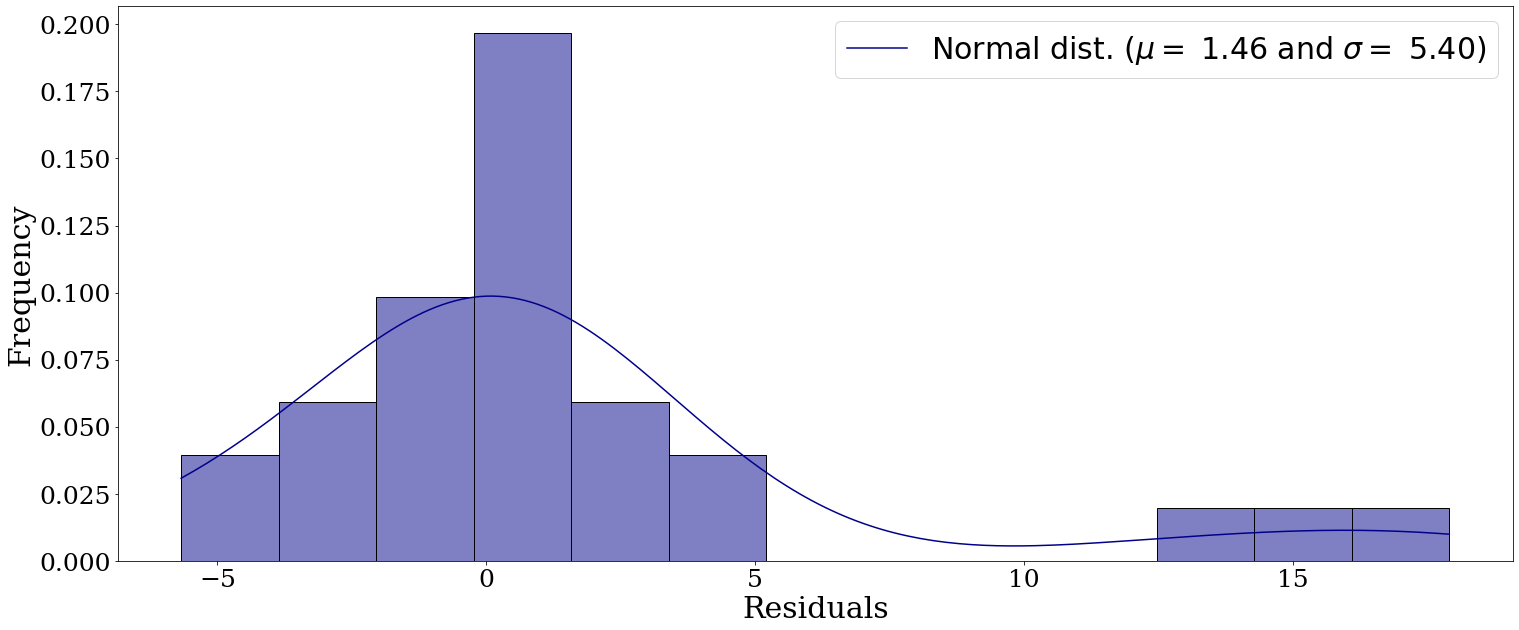

In [ ]:
##################################################################################################
# Test model accuracy
#################################################################################################

rmse = np.sqrt(mean_squared_error(y_test,Y_Test_Pred))
RSQ = r2_score(y_test,Y_Test_Pred)
MAPE = np.mean(np.abs((y_test - Y_Test_Pred) / y_test)) * 100
MAE = np.mean(np.abs(y_test - Y_Test_Pred))
print("############ Model Accuracy ############")
print("RMSE: %0.3f" % rmse)
print("R-squared: %0.3f" % RSQ)
print("MAPE: %0.3f" % MAPE)
print("MAE: %0.3f" % MAE)
print("########################################")
print(" ")

fig, ax1 = plt.subplots(1,1, figsize=(5,3.5))
####################################################################################################

ax1.scatter(y_test,Y_Test_Pred,
            marker='o', color = 'black')

ax1.text(0.95, 0.25, ("$RMSE$: %0.02f" % rmse),
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax1.transAxes,
        color='black', fontsize=21)

ax1.text(0.83, 0.1, ("$R^2$: %0.02f" % RSQ),
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax1.transAxes,
        color='black', fontsize=21)


ax1.set_xlabel('Actual $CS$ [MPa]', fontsize = 16)
ax1.tick_params(axis = "x", labelsize = 14, rotation=34)
ax1.xaxis.set_tick_params(pad=5)
ax1.set_ylabel('Predicted $CS$ [MPa]', fontsize = 16)
ax1.tick_params(axis = "y", labelsize = 14)
ax1.yaxis.set_tick_params(pad=5)


plt.tight_layout(pad=1.2)
fig.savefig('Scatter_Plot_With_Tuning.jpg', format='jpeg', dpi=300, bbox_inches='tight')

residuals = (y_test - Y_Test_Pred)
fig = plt.figure(figsize=(25, 10), dpi=72)
sns.histplot(residuals, kde=True, stat="density", color='darkblue')

(mu, sigma) = norm.fit(residuals)
plt.legend([r'Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f})'.format(mu, sigma)], loc='best', fontsize=30)
plt.xlabel('Residuals', fontsize=30, fontname='Serif')
plt.ylabel('Frequency', fontsize=30, fontname='Serif')
plt.xticks(fontsize=25, fontname='Serif')
plt.yticks(fontsize=25, fontname='Serif')
plt.figaspect(1.)
plt.title('')
# plt.savefig('Residual Distribution No Tuning.pdf')
plt.show()


# **SHAP ANALYSIS**


In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 7.3 MB/s eta 0:00:00


In [ ]:
import shap
shap.initjs()

In [ ]:
# Prepare the entire dataset
X_full = Data_DF[Feature_Names].to_numpy()

# Scale the entire dataset using the previously fitted scaler
X_full_scaled = scaler.transform(X_full)

# Create SHAP explainer using the entire dataset
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_full_scaled)

In [ ]:
# Convert scaled dataset to DataFrame (optional)
X_full_df = pd.DataFrame(X_full_scaled, columns=Feature_Names)

# Create a DataFrame for SHAP values (optional, for further analysis)
df_shap_plot = pd.DataFrame(shap_values, columns=Feature_Names)
df_shap_plot.head() # Display the first few rows of the SHAP values DataFrame

,Spodumene Flotation Tailings (wt.%),SILICA FUME (wt. %),Red Mud (wt.%),Metakaolin (wt.%),"Low-reactive Copper Mine Tailings (MT), g",Fly Ash (g),H3PO4 concentration (wt%),"Monoaluminum Phosphate, (wt ratio)","Aluminum Dihydrogen Phosphate Concentration, %",P/Si Ratio,P/Al Ratio,Curing Temperature (°C),Activation Temperature (°C),Liquid/Solid Ratio,Sand (wt.%),Age
0,-0.109820,0.064477,-0.089393,-10.173118,-0.207524,0.244622,-1.850335,-0.026372,-1.592845,-0.286999,-0.955395,-0.133226,0.842078,-0.039460,0.114193,-2.363100
1,-0.105793,0.072610,-0.091903,-9.756111,-0.113771,0.319803,-1.796451,-0.023952,-0.712740,0.105910,-0.190352,-0.141769,0.843904,-0.022335,0.114131,-3.032778
2,-0.105357,0.079190,-0.098573,-9.262908,-0.115355,0.255078,-1.749106,-0.023753,1.371877,0.042977,0.069670,-0.139650,0.843809,-0.011134,0.114029,-4.264673
3,-0.103307,0.073442,-0.105157,-8.903192,-0.113618,0.502628,-1.745692,-0.020391,2.900805,-0.014237,0.030448,-0.140486,0.836235,-0.015337,0.109770,-5.163487
4,-0.105586,0.084805,-0.105558,-8.160284,-0.108878,3.826815,-1.698650,-0.010909,3.268105,0.055847,0.026128,-0.081750,0.853333,0.277343,0.114283,-6.651184


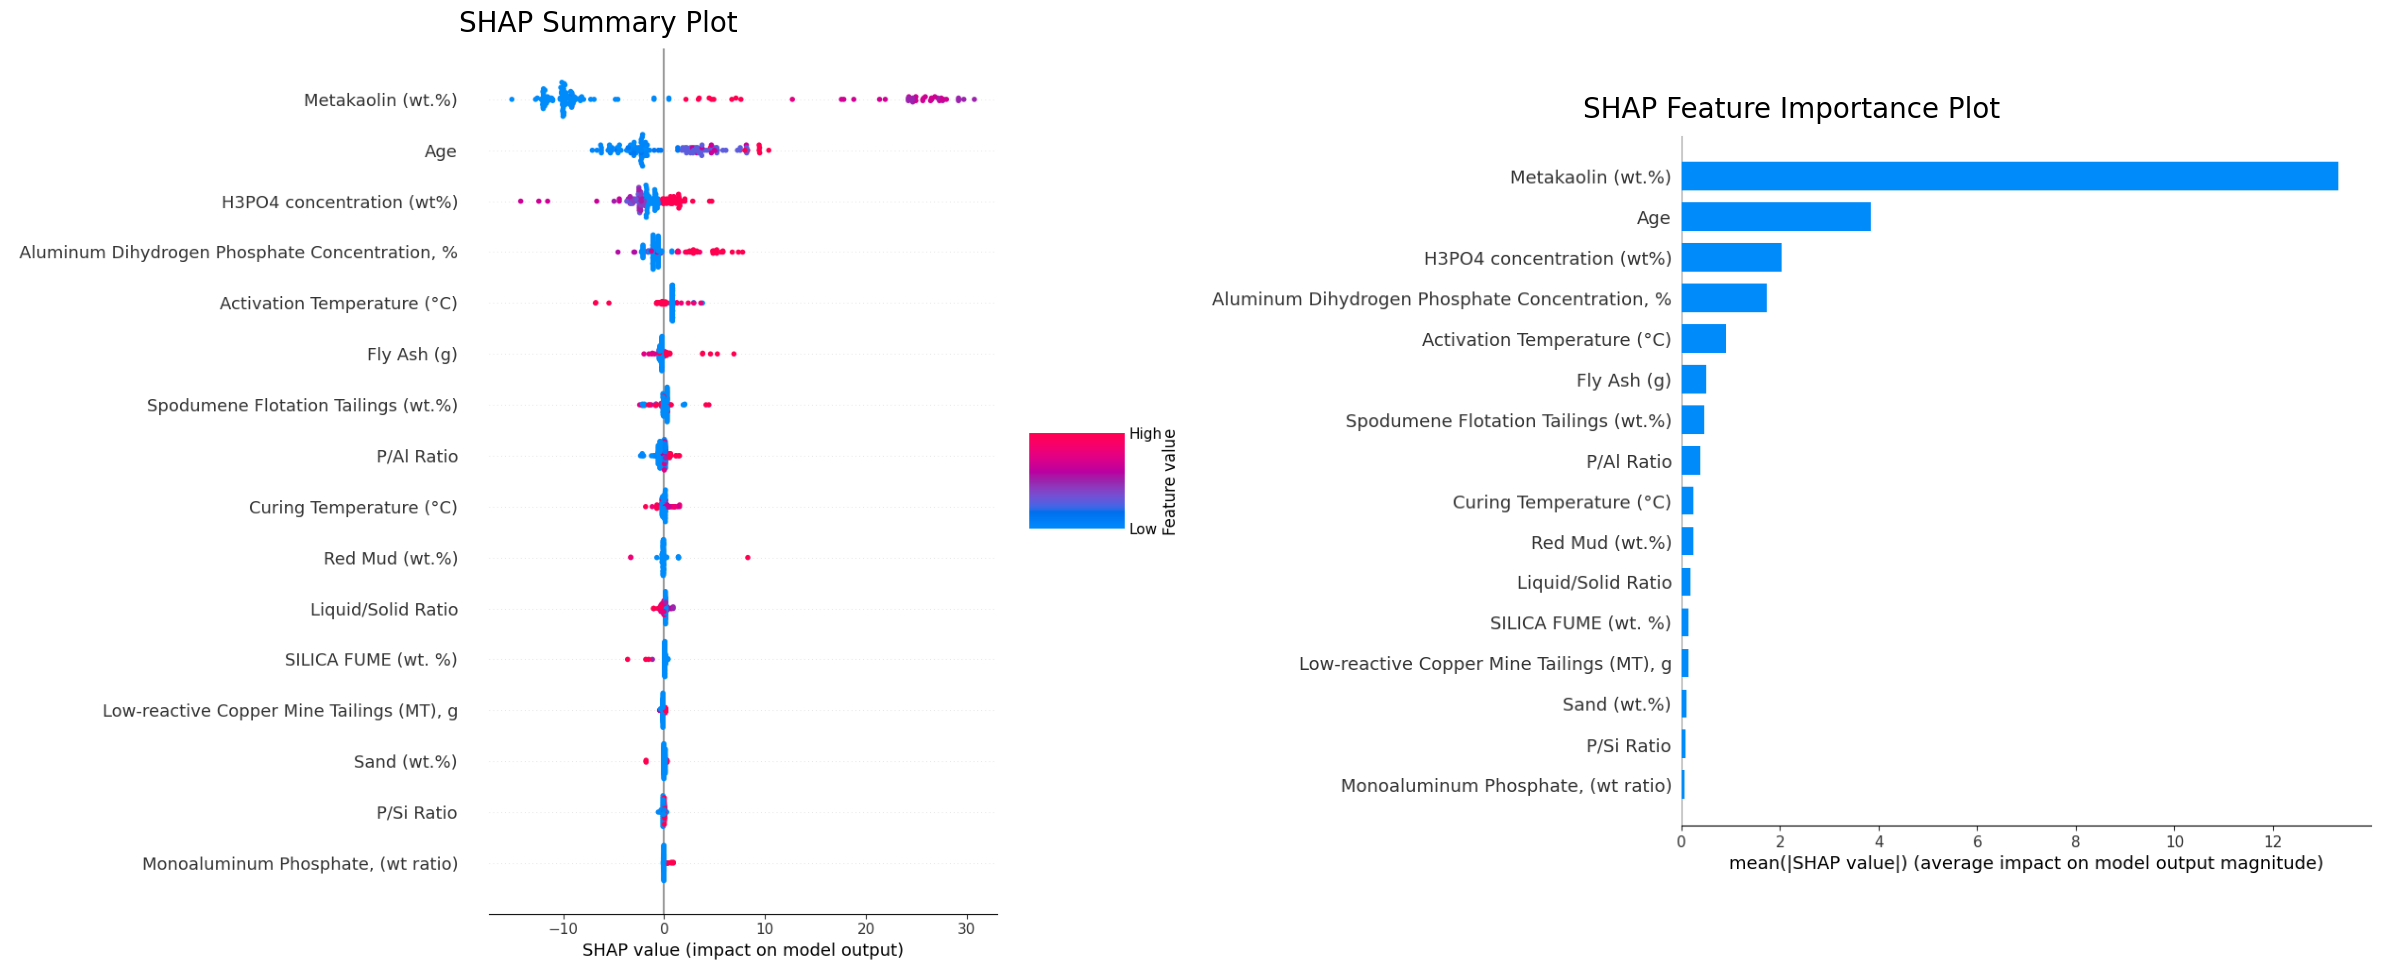

In [ ]:
# SHAP summary plot
shap.summary_plot(shap_values, X_full_df, plot_size=(12, 10), show=False)
plt.gcf().axes[-1].set_box_aspect(1)  # To maintain aspect ratio for color bar
plt.savefig('shap_summary_plot.png', bbox_inches='tight')
plt.close()

# SHAP feature importance plot
shap.summary_plot(shap_values, X_full_df, plot_type="bar", plot_size=(12, 10), show=False)
plt.gcf().axes[-1].set_box_aspect(1)  # To maintain aspect ratio for color bar
plt.savefig('shap_feature_importance_plot.png', bbox_inches='tight')
plt.close()

# Combine the saved plots into one figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Load and display the saved plots
img1 = plt.imread('shap_summary_plot.png')
img2 = plt.imread('shap_feature_importance_plot.png')

ax1.imshow(img1)
ax1.axis('off')
ax1.set_title('SHAP Summary Plot', fontsize=20)

ax2.imshow(img2)
ax2.axis('off')
ax2.set_title('SHAP Feature Importance Plot', fontsize=20)

plt.tight_layout()
plt.show()

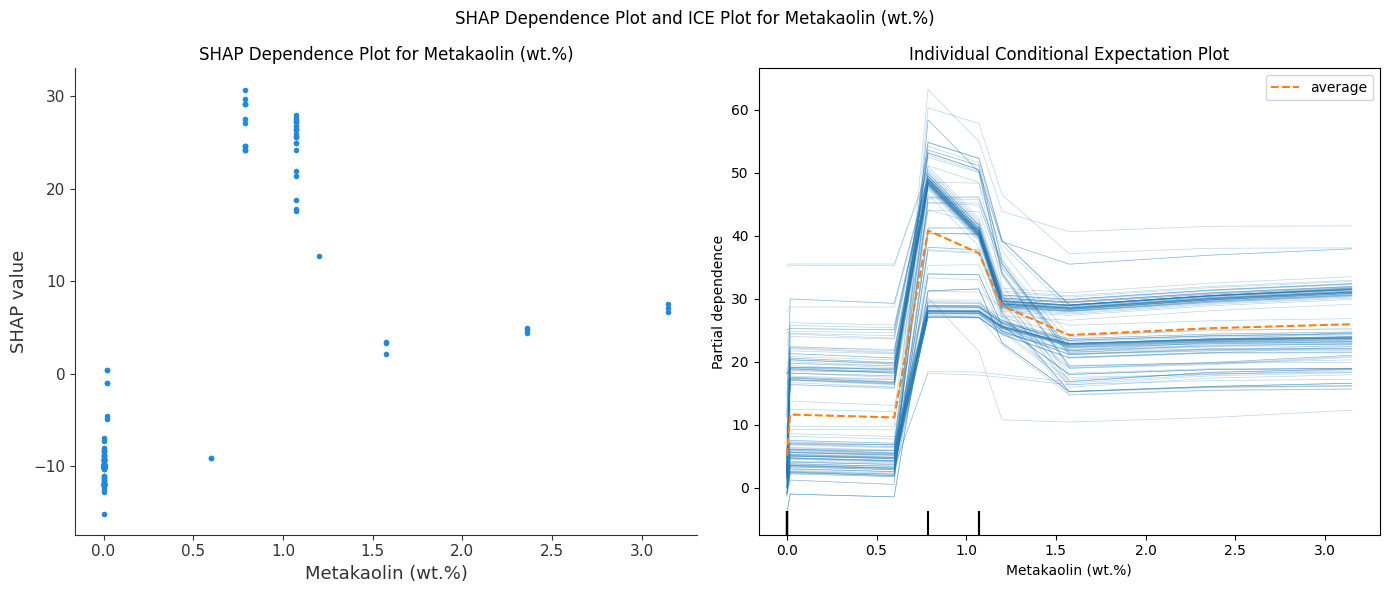

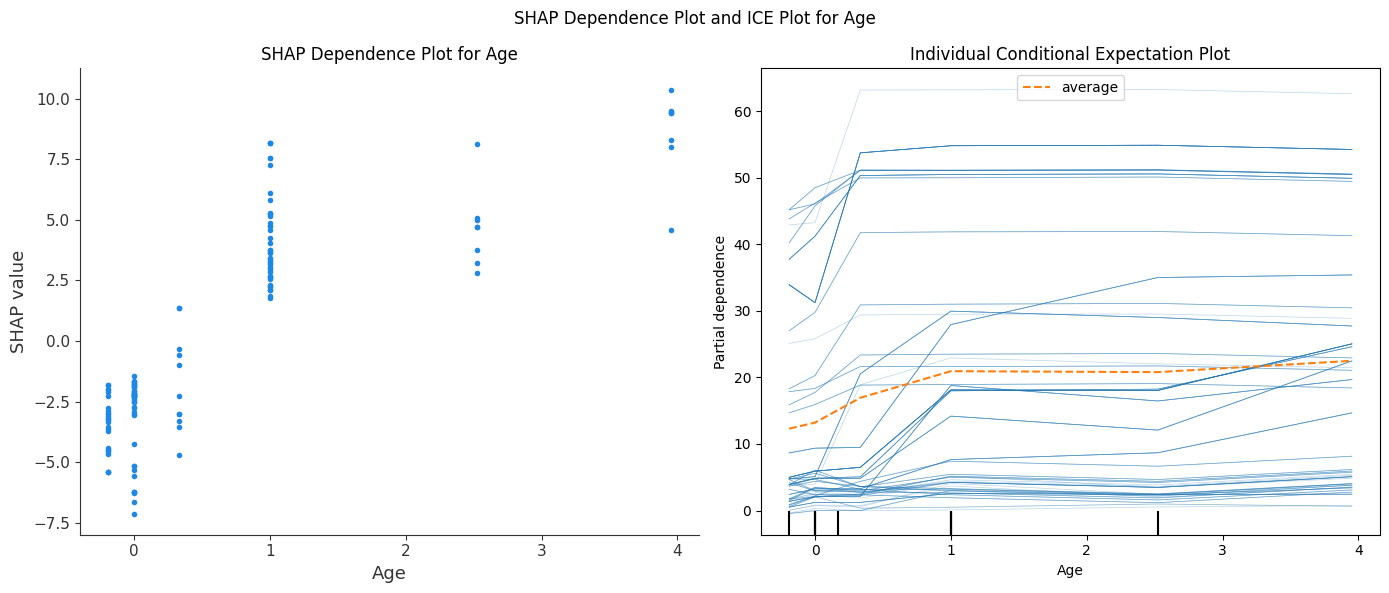

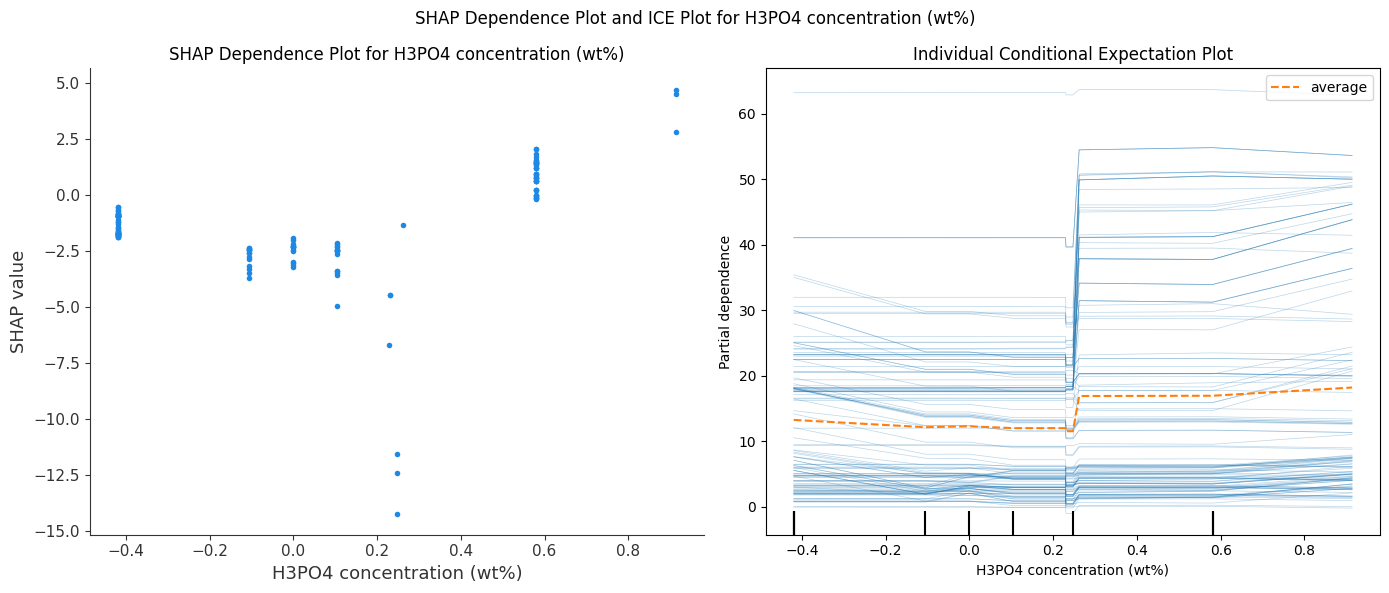

In [ ]:
# Function to create dependence plots
def create_dependence_plots(feature_name):
    if feature_name not in Feature_Names:
        raise ValueError(f"Feature '{feature_name}' not found in Feature_Names")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # SHAP Dependence Plot
    shap.dependence_plot(
        feature_name,
        shap_values,
        X_full_df,
        feature_names=Feature_Names,
        interaction_index=None,
        ax=ax1,
        show=False
    )

    # ICE Plot
    feature_index = Feature_Names.index(feature_name)
    pdp_disp = PartialDependenceDisplay.from_estimator(
        model,
        X_full_scaled,
        features=[feature_index],
        feature_names=Feature_Names,  # Ensure feature names are used
        kind='both',  # Use ICE plots
        grid_resolution=50,
        ax=ax2
    )

    # Get y-axis limits from ICE plot directly
    # Access the ICE lines directly from the axes object
    #ice_lines = ax2.lines
    #ice_predictions = np.array([line.get_ydata() for line in ice_lines])
    #y_min_ice = ice_predictions.min()
    #y_max_ice = ice_predictions.max()



    # Determine y-axis limits based on SHAP values and ICE plot predictions
    shap_values_for_feature = df_shap_plot[feature_name]
    y_min_shap = shap_values_for_feature.min()
    y_max_shap = shap_values_for_feature.max()

    #y_min = min(y_min_shap, y_min_ice)
    #y_max = max(y_max_shap, y_max_ice)

    # Adjust y-axis range
    #ax1.set_ylim(y_min, y_max)
    #ax2.set_ylim(y_min, y_max)

    # Set titles and labels
    ax1.set_title(f'SHAP Dependence Plot for {feature_name}')
    ax1.set_xlabel(feature_name)
    ax1.set_ylabel('SHAP value')

    ax2.set_title('Individual Conditional Expectation Plot')
    ax2.set_xlabel(feature_name)
    ax2.set_ylabel('Prediction')

    fig.suptitle(f'SHAP Dependence Plot and ICE Plot for {feature_name}')
    plt.subplots_adjust(top=0.9)  # Adjust title position
    plt.tight_layout()
    plt.show()

# List of top features to plot (top 5 from SHAP summary plot)
top_features = ['Metakaolin (wt.%)', 'Age', 'H3PO4 concentration (wt%)',
                'Aluminum Dihydrogen Phosphate Concentration, %', 'Activation Temperature (°C)']

# Create dependence plots for top features
for feature in top_features:
    create_dependence_plots(feature)